In [1]:
import sys
import os

sys.path.append(os.path.abspath("..")) 
import models

import matplotlib.pyplot as plt
import jax
import jax.numpy as jnp
from models.kuramoto_graph import KuramotoGraph

In [ ]:
G = KuramotoGraph(200)

G.positions()
G.distances()
A = G.distance_based_graphon()  # adjacency from ring graphon

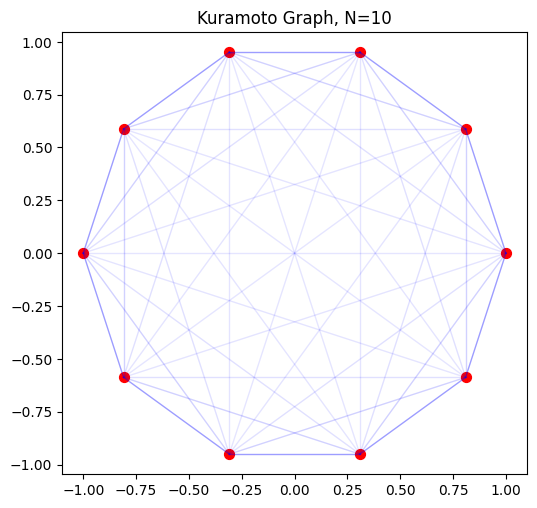

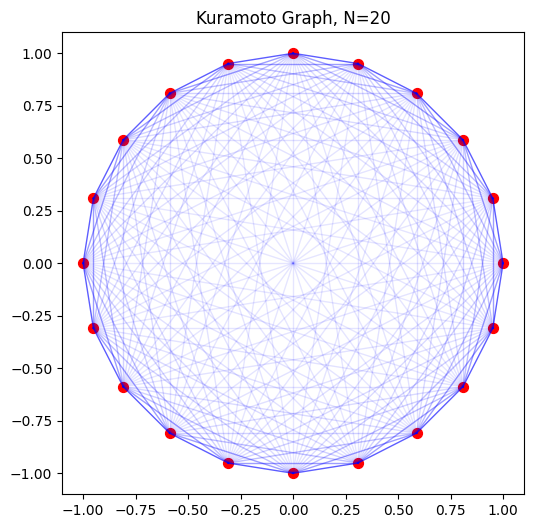

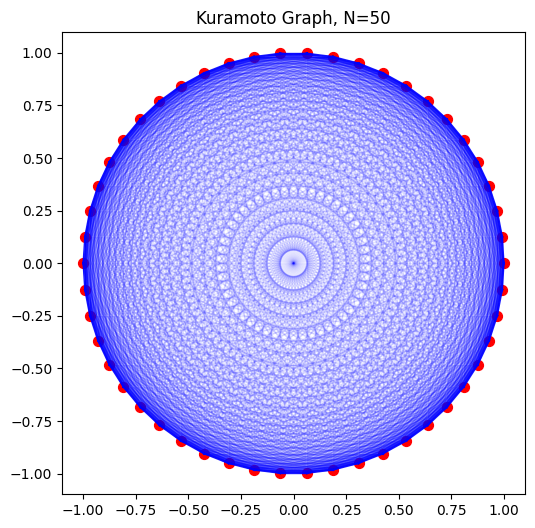

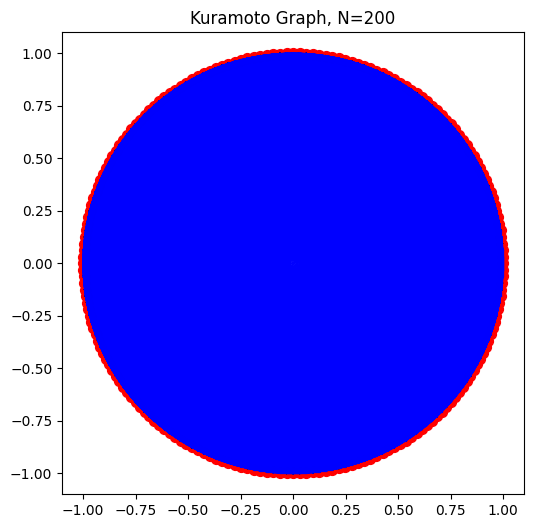

In [3]:
for i in [10, 20, 50, 200]:
    G = KuramotoGraph(i)

    G.positions()
    G.distances()
    A = G.distance_based_graphon()
    G.plot_graph(G.x, A)


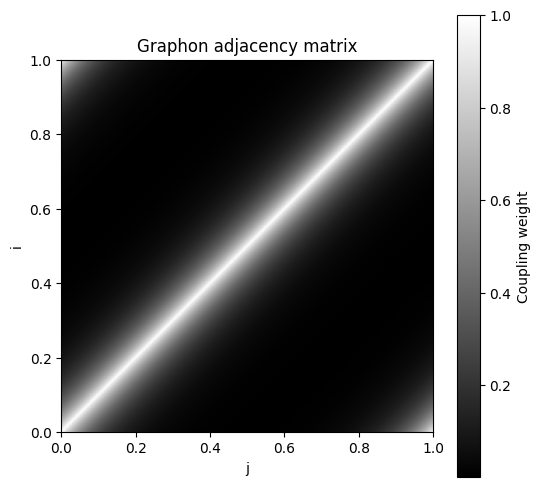

In [ ]:
G.plot_graphon(A)

In [ ]:
dt = 0.01
T=20

# simulate dynamics
sol = G.simulate(T=T, dt=dt)


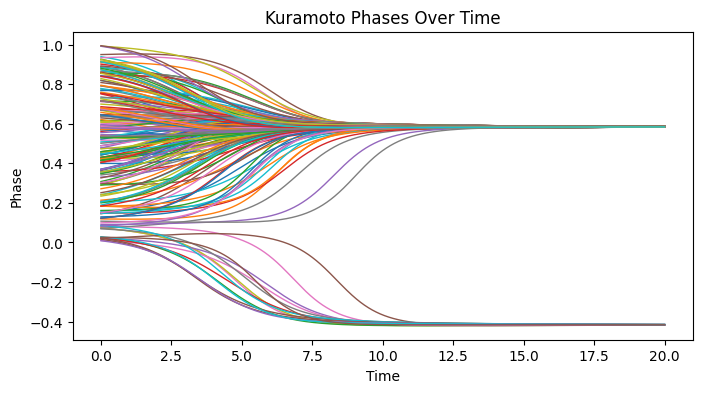

In [ ]:
plt.figure(figsize=(8,4))
for i in range(sol.ys.shape[1]):
    plt.plot(sol.ts, sol.ys[:, i], lw=1)
plt.xlabel('Time')
plt.ylabel('Phase')
plt.title('Kuramoto Phases Over Time')
plt.show()


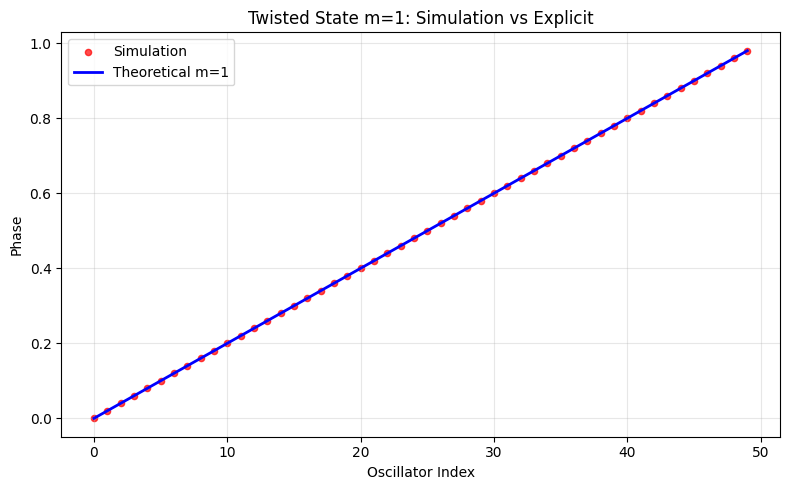

m=1: Order parameter = 0.000 (0=incoherent, 1=sync)


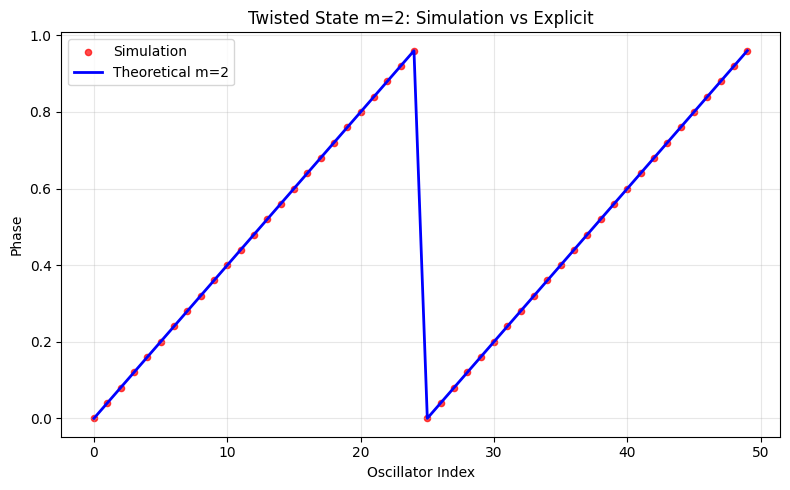

m=2: Order parameter = 0.000 (0=incoherent, 1=sync)


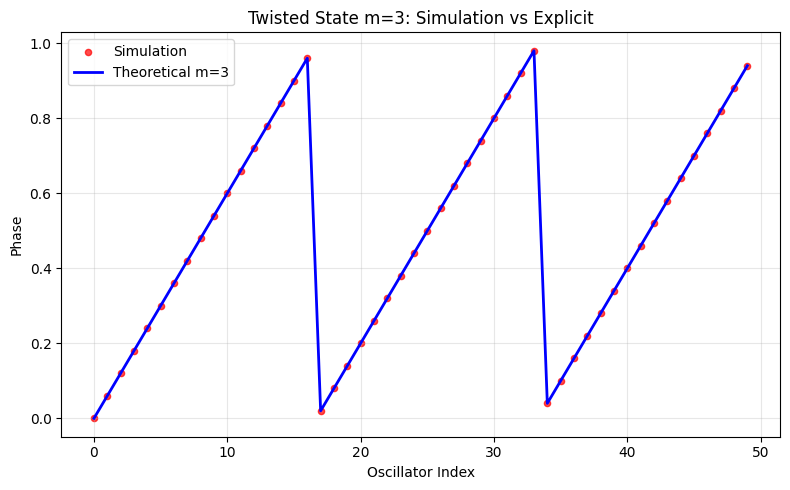

m=3: Order parameter = 0.000 (0=incoherent, 1=sync)


In [ ]:
def simulate_twisted_states(n=50):
    for m in [1, 2, 3]:  # Different numbers of twists
        u0_twisted = KuramotoGraph(n).m_twisted_state(m=m)
        G = KuramotoGraph(n, u0=u0_twisted)
        G.positions()
        G.distances()
        
        A = G.distance_based_graphon()
        G.A = A
        # simulate dynamics
        sol = G.simulate(T=20.0, dt=0.01)
        plot_twisted_state_comparison(G, sol, m=m)

def plot_twisted_state_comparison(G, sol, m=1):
    """Plot simulation results vs theoretical twisted state"""
    final_phases = sol.ys[-1]  # Final state
    theoretical_phases = G.m_twisted_state(m=m)

    oscillator_index = jnp.arange(G.n)

    plt.figure(figsize=(8, 5))
    plt.scatter(oscillator_index, final_phases, color='red', s=20, alpha=0.7, label='Simulation')
    plt.plot(oscillator_index, theoretical_phases, 'b-', linewidth=2, label=f'Theoretical m={m}')
    plt.xlabel('Oscillator Index')
    plt.ylabel('Phase')
    plt.title(f'Twisted State m={m}: Simulation vs Explicit')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()
    
    # Print synchronization measure
    order_param = jnp.abs(jnp.mean(jnp.exp(2j * jnp.pi * final_phases)))
    print(f"m={m}: Order parameter = {order_param:.3f} (0=incoherent, 1=sync)")

# Run the simulation
simulate_twisted_states(50)